In [4]:
#імпортуємо бібліотеки
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

### Етап підготовки даних

In [5]:
#імпортуємо набір даних
customer_set = pd.read_csv('shopping.csv')

In [6]:
# початкові дані
customer_set.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# прикінцеві дані
customer_set.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [8]:
#перегляд розміру набору даних
customer_set.shape

(200, 5)

In [9]:
#перевірка повноти набору даних
customer_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


З отриманих результатів бачимо, що всі 200 рядків містять ненульові дані. Зробимо ще одну перевірку, яка пвдраховує кількість NaN значень

In [10]:
customer_set.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
# Будуємо DataFrame з 3 та 4 стовпців, які використовуватимемо, як ознаки 
x=customer_set.iloc[:, [3,4]].values

### Етап побудови моделі

Реалізація алгоритму k-середніх для визначення оптимальної кількості кластерів. Завантажуємо Kmeans

In [12]:
from sklearn.cluster import KMeans
clalist=[]

Будемо використовувати метод Elbow для визначення k з параметром "k-means++"

In [13]:
#inertia_ - це метод, який розділяє точки даних на кластери
for i in range(1,11):
    kmeans = KMeans(n_clusters= i, init='k-means++', random_state=0)
    kmeans.fit(x)
    clalist.append(kmeans.inertia_)    

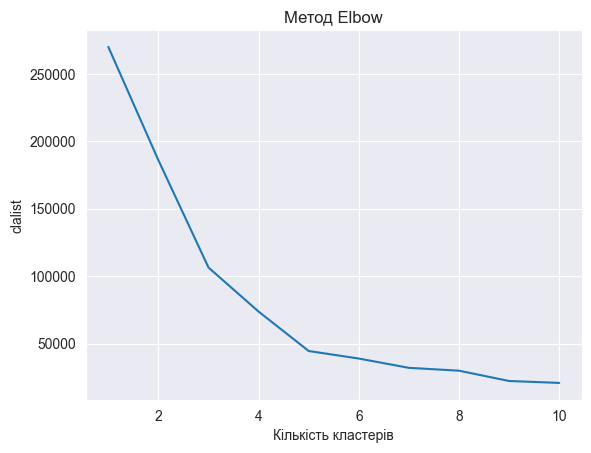

In [14]:
plt.plot(range(1,11), clalist)
plt.title('Метод Elbow')
plt.xlabel('Кількість кластерів')
plt.ylabel('clalist')
plt.show()

In [15]:
kmeansmodel = KMeans(n_clusters= 5, init='k-means++', random_state=0)
y_kmeans= kmeansmodel.fit_predict(x)
print(kmeansmodel.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


### Етап візуалізації

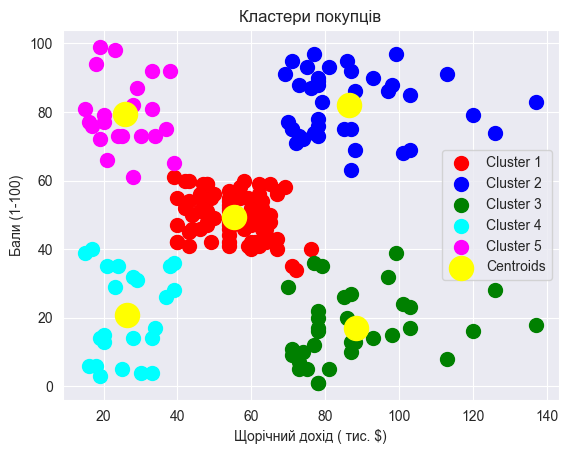

In [16]:
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeansmodel.cluster_centers_[:, 0], kmeansmodel.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Кластери покупців')
plt.xlabel('Щорічний дохід ( тис. $)')
plt.ylabel('Бали (1-100)')
plt.legend()
plt.show()